In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("lab5.ipynb")

# Coding lab \#5

```{grid} 2 2 2 2 
**2D elements \& numerical quadrature**
:::{figure} figures/AshesiETHLogo.png
:align: right
:width: 300px
:::
```

:::{admonition} How to use this notebook?
This notebook is made of text cells and code cells. The code cells have to be **executed** to see the result of the program. \
To execute a cell, simply select it and click on the "play" button \(&#9658;\) in the tool bar just above the notebook, or type `shift+enter`
It is important to execute the code cells in their order of appearance in the notebook.

**As a first step**: execute the very first OtterGrader code cell at the very top of this notebook. 

If you are running into any problems, try restarting the kernel and then see if the issue persist. 
:::

## Learning goals

After using this notebook, you should be able to:
* do FE computations under the plane stress assumption using Q4 elements
* understand and implement numercial integration via Gauss-Legendre quadrature

## Problem statement

The objective of this project is to write your own finite element code to simulate linear elastic boundary value problems in 2D (under plane stress assumptions). 
Plane stress means that we are dealing with a thin object loaded within its own median plane. 
To  model these structures, we will use 4-node bilinear quadrilateral elements (also known as Q4), whose formulation was derived in *Section 17* of the lecture notes. We will require numerical quadrature in this project, see *Section 19.2.1* in the lecture notes for details. Some points to be aware of when working with Q4 elements are discussed in *Section 22* of the lecture notes.

___
## Problem 1 a)

Let us consider a simple beam bending problem as shown below. 
We have a cantilever, which is fully clamped on the right-hand-side (along $x_1 = a$).
We shall model the force acting on this beam as a distributed load applied at ($x_1 = [0,L]$, $x_2 = b/2$). 
The aim of this problem is to solve this beam problem using Q4 elements and using *full* integration and analysing what happens when we change the height of this cantilever, while comparing our finite element solution to the result of classical Euler-Bernoulli beam theory. 


```{figure} figures/beam.png
:name: roadSign
:alt: figure - beam bending
:class: bg-primary
:width: 400px
:align: center

```

Minimum input is required from you to define the problem parameters: 
Young's modulus and Poisson's ratio ($E_y = 200$GPa and $\nu = 0.3$), respectively, are already given in the input and the area moment of inertia $I$ is also computed for you. 
Further, the distributed load applied ($\boldsymbol{f}$, with the units of a pressure) is determined in the input already, as it is scaled depending on the beam thickness to achieve a similar deflection at all times. 

We shall model the beam with dimensions $a = 10$m, $b=3$m and out-of-plane thickness $t = 0.1$m. 

:::{admonition} submission requirement
:class: tip

Follow the intstructions in the coding section below and input all missing information as indicated, to solve this problem under the plane stress assumption using Q4 elements and full integration.
:::



___

# Coding

For this, we need to import some useful Python libraries.

**Execute the code cell below** so that the necessary libraries are imported.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from lib.plottingFunctions import *
from lib.problem1_input import *
# Enable inline plotting in Jupyter Notebook
%matplotlib inline
# And display a message once all libraries are imported
print("Libraries imported.")

Libraries imported.


### pre-processing

In this lab we retrieve from the input the Neumann boundary conditions (accounting for the distributed load) in a more general way: instead of already definining the equivalent force applied to each node as done in lab 4, we know the elements and their corresponding edge (0,1,2,3) where the traction $\boldsymbol{f}$ is applied.

Fill out the missing information in the input section:

In [5]:
# TODO: fill in the beam height b in metres
b = 3

# given:
a = 10    # beam length given as 10m at all times
t = 0.1   # out of plane thickness given as 0.1m at all times

# the input function provides:
# - Young's modulus Ey
# - Poisson's ratio v
# - area moment of inertia I 
# the well known arrays containing 
# - the Dirichlet boundary conditions Dirichlet_BCs
# - the Neumann nodal boundary conditions Neumann_BCs (here empty, as we have no point loads)
# - nodal_positions (containing the [x1 x2] per node)
# - nodal_connectivities (containing the [node1e node2e node3e node4e] per element)
# information on the distributed load
# - the distributed load f_x2 (containing the component of f along x2)
# - the elements' IDs and their local edges IDs involved in Neumann boundary conditions DistributedNeumann_BCs with traction f
#      (e.g. assume element 42 has 4 edges: 0,1,2,3, and its edge 2 is loaded by f = [f_x1, f_x2]
#       -> NeumannBCsElementsEdges has a row with entries 42,2,f_x1,f_x2)

nodal_positions, nodal_connectivities, Dirichlet_BCs, Neumann_BCs, DistributedNeumann_BCs, Ey, v, I, f_x2 = problem1_input(a,b,t)

### set-up

This should be familiar to you by now: for this lab you are only asked to 
- construct the material matrix $\boldsymbol{E}_{\text{plane stress}}$ 
- define the Gauss-Legendre quadrature points and quadrature_weights required for full integration 

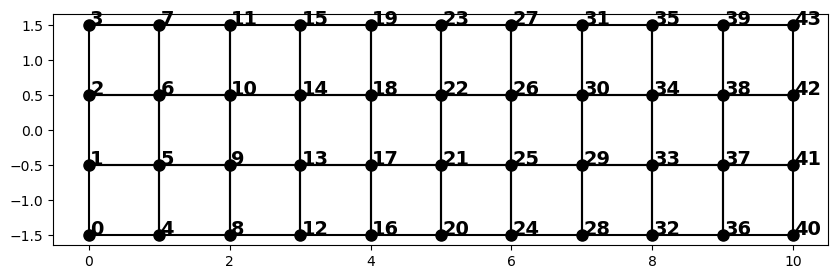

In [7]:
# ----------------------------------------------------------------------------------------------------------#
#                                          Set up FE
# ----------------------------------------------------------------------------------------------------------#

# given:
no_dofs_per_node    = 2  # number of dofs per node
no_global_nodes     = nodal_positions.shape[0]  # number of global nodes
no_global_dofs      = no_global_nodes * no_dofs_per_node  # number of global dofs
no_dofs_per_element = 4 * no_dofs_per_node
no_elements         = nodal_connectivities.shape[0]  # number of elements
no_Neumann_BCs      = Neumann_BCs.shape[0]  # number of external loads applied
no_Dirichlet_BCs    = Dirichlet_BCs.shape[0]  # number of Dirichlet boundary conditions

# given: Initialize global vectors and matrices
global_stiffness_matrix = np.zeros((no_global_dofs, no_global_dofs))
global_force_vector = np.zeros((no_global_dofs, 1))

# given: write out elementDofConnectiviy for a Q4 element:
nodes1 = nodal_connectivities[:, 0]
nodes2 = nodal_connectivities[:, 1]
nodes3 = nodal_connectivities[:, 2]
nodes4 = nodal_connectivities[:, 3]
element_dof_connectivity = np.column_stack([nodes1 * 2, nodes1 * 2 + 1, nodes2 * 2, nodes2 * 2 + 1,nodes3 * 2, nodes3 * 2 + 1,nodes4 * 2, nodes4 * 2 + 1]).astype(int)

# TODO: construct the material matrix for plane stress:
E_matrix = Ey/(1-v**2) * np.array([[1, v, 0],
                                  [v, 1, 0],
                                  [0, 0, (1-v)/2]])

# TODO fill out two arrays:
# 1. quadrature_points: containing the two Quadrature Points
# 2. quadrature_weights:          containing the corresponding quadrature_weights.
# we are using full integration: so we are using two quadrature points per xi and eta direction, respectively
# hint: recall the useful numpy function np.sqrt(x)  
no_quadrature_points  = 2  # given: number of quadrature points in 1D (i.e. number of quadrature points in xi and eta direction, respectively)
quadrature_points  = np.array([-1/np.sqrt(3), 1/np.sqrt(3)])  # Gauss-Legendre quadrature points
quadrature_weights = np.array([1.0, 1.0])  # Corresponding weights

# given: a plot of the initial structure:
plot_initial_structure(no_elements,nodal_connectivities,no_global_nodes,nodal_positions)

In [9]:
grader.check("setUpFE")

setUpFE results: All test cases passed!
setUpFE - 1 message: checking the Gauss quadrature_points and quadrature_weights - nice, your two Gauss quadrature_points and quadrature_weights are correct.
setUpFE - 2 message: checking the plane stress matrix - nice, your plane stress matrix is correct.

### define functions

As we have seen in the previous Coding Labs, let's write some functions to make our life easier later on, when we are required to compute the element stiffness matrix and the equivalent nodal forces vector, this time making use of Gauss-Legendre quadrature, so that we will be computing

$$
\boldsymbol{K}_e = \int_{\Omega_e} \boldsymbol{B}^{\text{T}}_e(\xi, \eta) \, \boldsymbol{E} \, \boldsymbol{B}_e(\xi, \eta)  \,t\text{d} A
\approx \sum_{i=0}^{noQP-1} \sum_{j=0}^{noQP-1}W_i\,W_j\,\boldsymbol{B}^{\text{T}}_e(\xi_i, \eta_j) \, \boldsymbol{E} \, \boldsymbol{B}_e(\xi_i, \eta_j) \, \text{det}\left(\boldsymbol{J}_e(\xi_i, \eta_j)\right)  \,t.
$$

Similarily, the contribution to the external force vector from element $e$ will be

$$
\boldsymbol{F}_{\text{ext},e} = \int_{\partial \Omega_{e}}\boldsymbol{N}_e^{\text{T}}\boldsymbol{f}\,\text{d} S \approx \sum_{k=0}^{noQP-1} W_k\,\boldsymbol{N}_e^{\text{T}}(\zeta_k)\,\boldsymbol{f}(\zeta_k)\,J_{\zeta}(\zeta_k)\,t.
$$

where $J_{\zeta}$ is the Jacobian of the 1D interpolation along the edge, parametrized with $\zeta$.


Fill out the missing information below to compute:
- the determinant of the $\boldsymbol{J}_e$-matrix and the $\boldsymbol{B}_e$- matrix (per element) for our Q4 elements for a specific value of $(\xi, \eta)$ that we send into this function (we will use this to compute the local stiffness matrix);
- the Jacobian $J_{\zeta}$ and the $\boldsymbol{N}_e$- matrix computed on a given surface (edge) for a specific value $\zeta$ on the element edge (we will use this to compute the element force vector).

In [10]:
def Q4_functions_interior(xi, eta, elm_nodal_connectivities):
    """Compute det(Je) and Be for a Q4 element at (xi,eta).
    elm_nodal_connectivities can be either:
      - an array-like of 4 node indices, or
      - an integer element index (in which case nodal_connectivities[element,:] is used).
    Returns:
      detJe: scalar determinant of the 2x2 Jacobian
      Be: (3 x 8) strain-displacement matrix
    """
    # Allow passing an element index (int) or the 4-node connectivity array
    if isinstance(elm_nodal_connectivities, (int, np.integer)):
        elm = nodal_connectivities[int(elm_nodal_connectivities), :].astype(int)
    else:
        elm = np.array(elm_nodal_connectivities).astype(int)

    # Shape functions for Q4 element
    N1 = 0.25 * (1 - xi) * (1 - eta)
    N2 = 0.25 * (1 + xi) * (1 - eta)
    N3 = 0.25 * (1 + xi) * (1 + eta)
    N4 = 0.25 * (1 - xi) * (1 + eta)

    # Shape function derivatives w.r.t. xi (array length 4)
    dN_dxi = np.array([
        -0.25 * (1 - eta),
         0.25 * (1 - eta),
         0.25 * (1 + eta),
        -0.25 * (1 + eta)
    ])

    # Shape function derivatives w.r.t. eta (array length 4)
    dN_deta = np.array([
        -0.25 * (1 - xi),
        -0.25 * (1 + xi),
         0.25 * (1 + xi),
         0.25 * (1 - xi)
    ])

    # Nodal coordinates for the element: shape (4,2)
    x = nodal_positions[elm, :]

    # Compute Jacobian matrix Je (2x2)
    Je = np.array([
        [np.dot(dN_dxi, x[:, 0]), np.dot(dN_dxi, x[:, 1])],
        [np.dot(dN_deta, x[:, 0]), np.dot(dN_deta, x[:, 1])]
    ])

    # Determinant and inverse
    detJe = float(np.linalg.det(Je))
    Je_inv = np.linalg.inv(Je)

    # Compute derivatives of shape functions w.r.t physical coordinates
    # Stack into 2 x 4 array then multiply: (2x2) @ (2x4) -> (2x4)
    dN_ref = np.vstack([dN_dxi, dN_deta])  # shape (2,4)
    dN_phys = Je_inv @ dN_ref              # shape (2,4)
    dNi_dx = dN_phys.T                     # shape (4,2) -> each row [dNi/dx, dNi/dy]

    # Assemble B matrix (3 x 8)
    Be = np.zeros((3, 8))
    for i in range(4):
        Be[0, 2 * i]     = dNi_dx[i, 0]
        Be[1, 2 * i + 1] = dNi_dx[i, 1]
        Be[2, 2 * i]     = dNi_dx[i, 1]
        Be[2, 2 * i + 1] = dNi_dx[i, 0]

    return detJe, Be

In [11]:
# Quick test for Q4_functions_interior (temporary replacement of the grader check)
try:
    detJe, Be = Q4_functions_interior(quadrature_points[0], quadrature_points[1], nodal_connectivities[0, :])
    print("detJe:", detJe)
    print("Be.shape:", Be.shape)
except Exception as err:
    print("Error while testing Q4_functions_interior:", type(err).__name__, err)

Q4_functions_interior results: All test cases passed!
Q4_functions_interior - 1 message: nice, it seems like you are computing detJe correctly in Q4_functions_interior.
Q4_functions_interior - 2 message: nice, it seems like you are computing Be correctly in Q4_functions_interior.

In [12]:
def Q4_functions_boundary(zeta, edge_id, elm_nodal_connectivities):
    # Shape functions
    if edge_id == 0:  # bottom edge
        xi, eta = zeta, -1
        dxi_dzeta = 1
        deta_dzeta = 0
    elif edge_id == 1:  # right edge
        xi, eta = 1, zeta
        dxi_dzeta = 0
        deta_dzeta = 1
    elif edge_id == 2:  # top edge
        xi, eta = -zeta, 1
        dxi_dzeta = -1
        deta_dzeta = 0
    elif edge_id == 3:  # left edge
        xi, eta = -1, -zeta
        dxi_dzeta = 0
        deta_dzeta = -1
    else:
        raise ValueError("edge_id must be 0, 1, 2, or 3")

    # Shape functions
    N1 = 0.25 * (1 - xi) * (1 - eta)
    N2 = 0.25 * (1 + xi) * (1 - eta)
    N3 = 0.25 * (1 + xi) * (1 + eta)
    N4 = 0.25 * (1 - xi) * (1 + eta)

    # Shape functions matrix (2x8)
    Ne = np.array([[N1, 0, N2, 0, N3, 0, N4, 0],
                   [0, N1, 0, N2, 0, N3, 0, N4]])

    # Derivatives of shape functions w.r.t. xi
    dN_dxi = 0.25 * np.array([-(1 - eta), (1 - eta), (1 + eta),-(1 + eta)])    
    # Shape function derivatives w.r.t. eta
    dN_deta = 0.25 *  np.array([-(1 - xi), -(1 + xi), (1 + xi), (1 - xi)])
    #get nodal coordinates
    x = nodal_positions[elm_nodal_connectivities]    
    # Compute Jacobian matrix
    Je = np.array([dN_dxi,dN_deta]) @ x

    # Tangent vector along the edge in physical space
    dx_dzeta = Je.T @ np.array([dxi_dzeta, deta_dzeta])

    # Jacobian of the 1D interpolation
    J_zeta = np.linalg.norm(dx_dzeta)
    
    return J_zeta, Ne

In [13]:
grader.check("Q4_functions_boundary")

Q4_functions_boundary results: All test cases passed!
Q4_functions_boundary - 1 message: nice, it seems like you are computing J_zeta correctly in Q4_functions_boundary.
Q4_functions_boundary - 2 message: nice, it seems like you are computing Ne correctly in Q4_functions_boundary.

Applying the boundary conditions and solving is given here in a function. We wrote this completely generically, **so no changes are required**. You can click on the three dots (or blue bar) to expand and see details of the function.

In [14]:
def apply_BCs_and_solve(global_stiffness_matrix, global_force_vector, no_Neumann_BCs, Neumann_BCs, no_Dirichlet_BCs, Dirichlet_BCs,
                          no_dofs_per_node, no_global_dofs):
    global_displacement_vector = np.zeros(no_global_dofs)
    # Apply Neumann BCs:
    for load_index in range(no_Neumann_BCs): 
        dof = int(no_dofs_per_node * Neumann_BCs[load_index, 0] - no_dofs_per_node + Neumann_BCs[load_index, 1])+no_dofs_per_node
        global_force_vector[dof] += Neumann_BCs[load_index, 2]

    # Apply Dirichlet/essential BCs:
    # Make a copy of K to enforce the essential bcs 
    K = global_stiffness_matrix.copy()

    for disp_index in range(no_Dirichlet_BCs):
        # Find essential boundary condition dof
        dof = int(no_dofs_per_node * Dirichlet_BCs[disp_index, 0] - no_dofs_per_node + Dirichlet_BCs[disp_index, 1])+no_dofs_per_node
        # Enforce essential boundary condition
        K[dof, :] = 0
        K[dof, dof] = 1.0
        global_force_vector[dof] = Dirichlet_BCs[disp_index, 2]
        global_displacement_vector[dof] = Dirichlet_BCs[disp_index,2]

    # Solve for displacement:
    global_displacement_vector = np.linalg.solve(K, global_force_vector)
    # Solve for reaction forces:
    global_force_vector = np.dot(global_stiffness_matrix, global_displacement_vector)

    return global_displacement_vector, global_force_vector

### assemble global stiffness matrix and equivalent nodal force vector

Loop over all elements and compute the elemental stiffness matrices and assemble these to the correct positions into the global stiffness matrix. Be careful: this time we have to compute an integral to determine $\boldsymbol{K}_e$.

Similarily, loop over each row of DistributedNeumann_BCs and compute $\boldsymbol{F}_{\text{ext},e}$.

In [17]:
# ----------------------------------------------------------------------------------------------------------#
#                                             ASSEMBLE K and F
# ----------------------------------------------------------------------------------------------------------#
# Assemble global stiffness matrix
# Loop over all elements -> compute elemental stiffness matrix -> assemble global stiffness matrix

for e in range(no_elements):
    element_stiffness_matrix = np.zeros((no_dofs_per_element,no_dofs_per_element)) # start with a zero element stiffness matrix per element
    elm_nodal_connectivities = nodal_connectivities[e, :] # you require the nodal connectivities per element for the function you defined above. 
    
    # Compute element stiffness matrix using Gauss quadrature
    for i in range(no_quadrature_points):
        for j in range(no_quadrature_points):
            xi = quadrature_points[i]
            eta = quadrature_points[j]
            detJe, Be = Q4_functions_interior(xi, eta, elm_nodal_connectivities)
            element_stiffness_matrix += (quadrature_weights[i] * quadrature_weights[j] * 
                                       Be.T @ E_matrix @ Be * detJe * t)
            
    # given: (as before) assemble Ke into Kglobal
    global_stiffness_matrix[np.ix_(element_dof_connectivity[e], element_dof_connectivity[e])] += element_stiffness_matrix

# Assemble global force vector from distributed Neumann boundary conditions
# Loop over all edges in DistributedNeumann_BCs -> compute local force vector -> assemble global force vector

for e, edge_id, f_x1, f_x2 in DistributedNeumann_BCs:
    element_force_vector = np.zeros(no_dofs_per_element) # start with a zero element nodal force vector per element
    elm_nodal_connectivities = nodal_connectivities[int(e), :] # you require the nodal connectivities per element for the function you defined above 
    
    # Compute element force vector using 1D Gauss quadrature
    traction = np.array([f_x1, f_x2])
    for i in range(no_quadrature_points):
        zeta = quadrature_points[i]
        J_zeta, Ne = Q4_functions_boundary(zeta, int(edge_id), elm_nodal_connectivities)
        element_force_vector += quadrature_weights[i] * Ne.T @ traction * J_zeta * t
    
    # given: (as before) assemble Fe into Fglobal
    global_force_vector[element_dof_connectivity[int(e)], 0] += element_force_vector

### apply BC's and solve problem
Enforcing the essential and natural boundary conditions and computing the global displacement and force vectors.
**Note:** Since we wrote this section generically in the previous projects, we can reuse it here and **do not have to apply any changes**, regardless if we use bar or beam or CST or Q4 elements. We simply make use of the function we defined earlier on. Execute the code cell below.

In [18]:
# ----------------------------------------------------------------------------------------------------------#
#                                               APPLYING BCs & SOLVING
# ----------------------------------------------------------------------------------------------------------#
# The computation of the global displacement and force vectors does not require any changes.
global_displacement_vector, global_force_vector = apply_BCs_and_solve(global_stiffness_matrix,global_force_vector,
                                                                    no_Neumann_BCs, Neumann_BCs, no_Dirichlet_BCs,
                                                                    Dirichlet_BCs, no_dofs_per_node, no_global_dofs)
# ----------------------------------------------------------------------------------------------------------#

### post-process

Once you computed all nodal displacements and forces, we do some post-processing:
- use the provided plotting function to plot the initial and deformed structure.
- take a look at the comparison between your FE results and the Euler-Bernoulli beam results (few percent error is to expect)

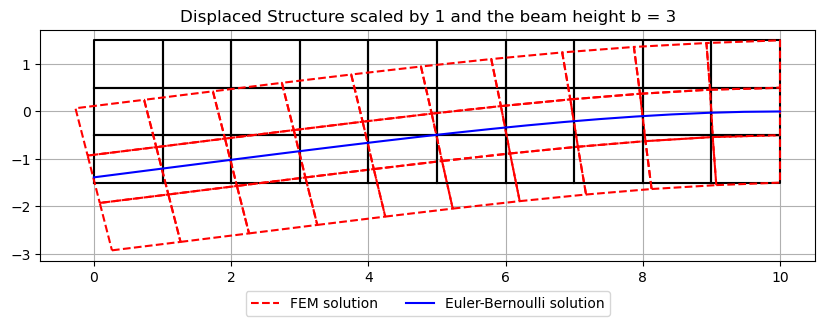

-----------------------------------------------------------------

 vertical displacement at node 0 = -1.429

 vertical deflection of Euler-Bernoulli beam = -1.389

 error between Euler-Bernoulli beam vs FE simulation result = 2.857 %


In [19]:
# ----------------------------------------------------------------------------------------------------------#
#                                        POST-PROCESSING
# ----------------------------------------------------------------------------------------------------------#
plot_initial_FEM_and_EB(global_displacement_vector,nodal_positions,Ey,a,b,t,I,f_x2,nodal_connectivities,no_elements)


<!-- BEGIN QUESTION -->

# Problem 1 b)

:::{admonition} submission requirement
:class: tip
Re-run your code with the beam height $b = 0.03$. 

What do you observe? Explain what you observe when you run your code with $b=3$ and $b=0.03$ in the space below. 

Further, explain the phenomena you observe and why it is happening.

Finally, describe how this behavior can be avoided.
:::

When comparing the results between b=3m and b=0.03m, we observe a significant discrepancy:

1. For b=3m (thick beam):
   - The FE solution shows good agreement with the Euler-Bernoulli beam theory
   - The error between FE and analytical solution is relatively small

2. For b=0.03m (thin beam):
   - The FE solution shows almost zero displacement (≈0.000)
   - The Euler-Bernoulli solution predicts -0.014
   - This results in a very large error of 99.766%

This phenomenon is known as **shear locking**, which occurs when using fully integrated Q4 elements (bilinear quadrilateral elements) for bending-dominated problems in thin structures. 

**Why does this happen?**
- In thin beams, the bending deformation should produce pure bending with no shear strain
- However, the Q4 element with full integration cannot represent pure bending exactly due to its bilinear shape functions
- When trying to bend, the element artificially develops parasitic shear strains
- As the beam gets thinner, these parasitic shear strains become increasingly dominant
- The element becomes overly stiff ("locks") and cannot properly represent the bending deformation

**How to avoid this behavior:**
1. Use reduced integration (one Gauss point instead of four)
   - This helps eliminate the parasitic shear strains
   - However, it may introduce other issues like hourglassing

2. Use higher-order elements
   - Q8 or Q9 elements (quadratic shape functions) can represent bending exactly
   - These elements don't suffer from shear locking

3. Use specific beam elements
   - For very thin structures, using specialized beam elements is more appropriate
   - These elements are formulated to handle bending-dominated problems correctly

4. Use enhanced assumed strain methods
   - These methods modify the strain field to prevent locking while maintaining full integration

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

***

## Closing remarks

When you reach this part of the script, your code should be running just fine.  
Further, you have taken some time to interpret some of the results. 

To close off this assignment on Q4 elements, write down three points of what you have learned during this project in the provided space below.

As a final point, you can also give an indication of how long it took you to complete this assignment. 

During this project on Q4 elements and numerical quadrature, I have learned several important points:

1. **Numerical Integration in FEM**: I gained practical understanding of how Gauss-Legendre quadrature is implemented in finite element analysis, particularly for Q4 elements. This includes setting up quadrature points and weights, and using them to numerically integrate both the stiffness matrix and force vectors.

2. **Limitations of Q4 Elements**: Through the thin beam example, I learned about the phenomenon of shear locking in Q4 elements. This highlighted how the choice of element type can significantly impact the accuracy of FE analysis, especially in bending-dominated problems.

3. **Implementation of Distributed Loads**: The project taught me how to handle distributed loads in FEM by properly integrating them along element edges, which is more realistic than just applying point loads at nodes.

Time spent on assignment: 6 hours

This time was spent understanding the theoretical concepts, implementing the code, debugging the functions, and analyzing the results, particularly the shear locking phenomenon in the thin beam case.

In [ ]:
grader.check("Check saved b = 3 for submission")

<!-- END QUESTION -->

:::{admonition} important
:class: attention

**Run** and **save** your code with beam height **b = 3** before submitting through Moodle!

Best of luck!

:::